# MAB: Multi Armed Bandit. Seminar 1  


*  ## UCB --------->>>>> HW
*  ## $\varepsilon$ - greedy    <<<<<<---------




In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

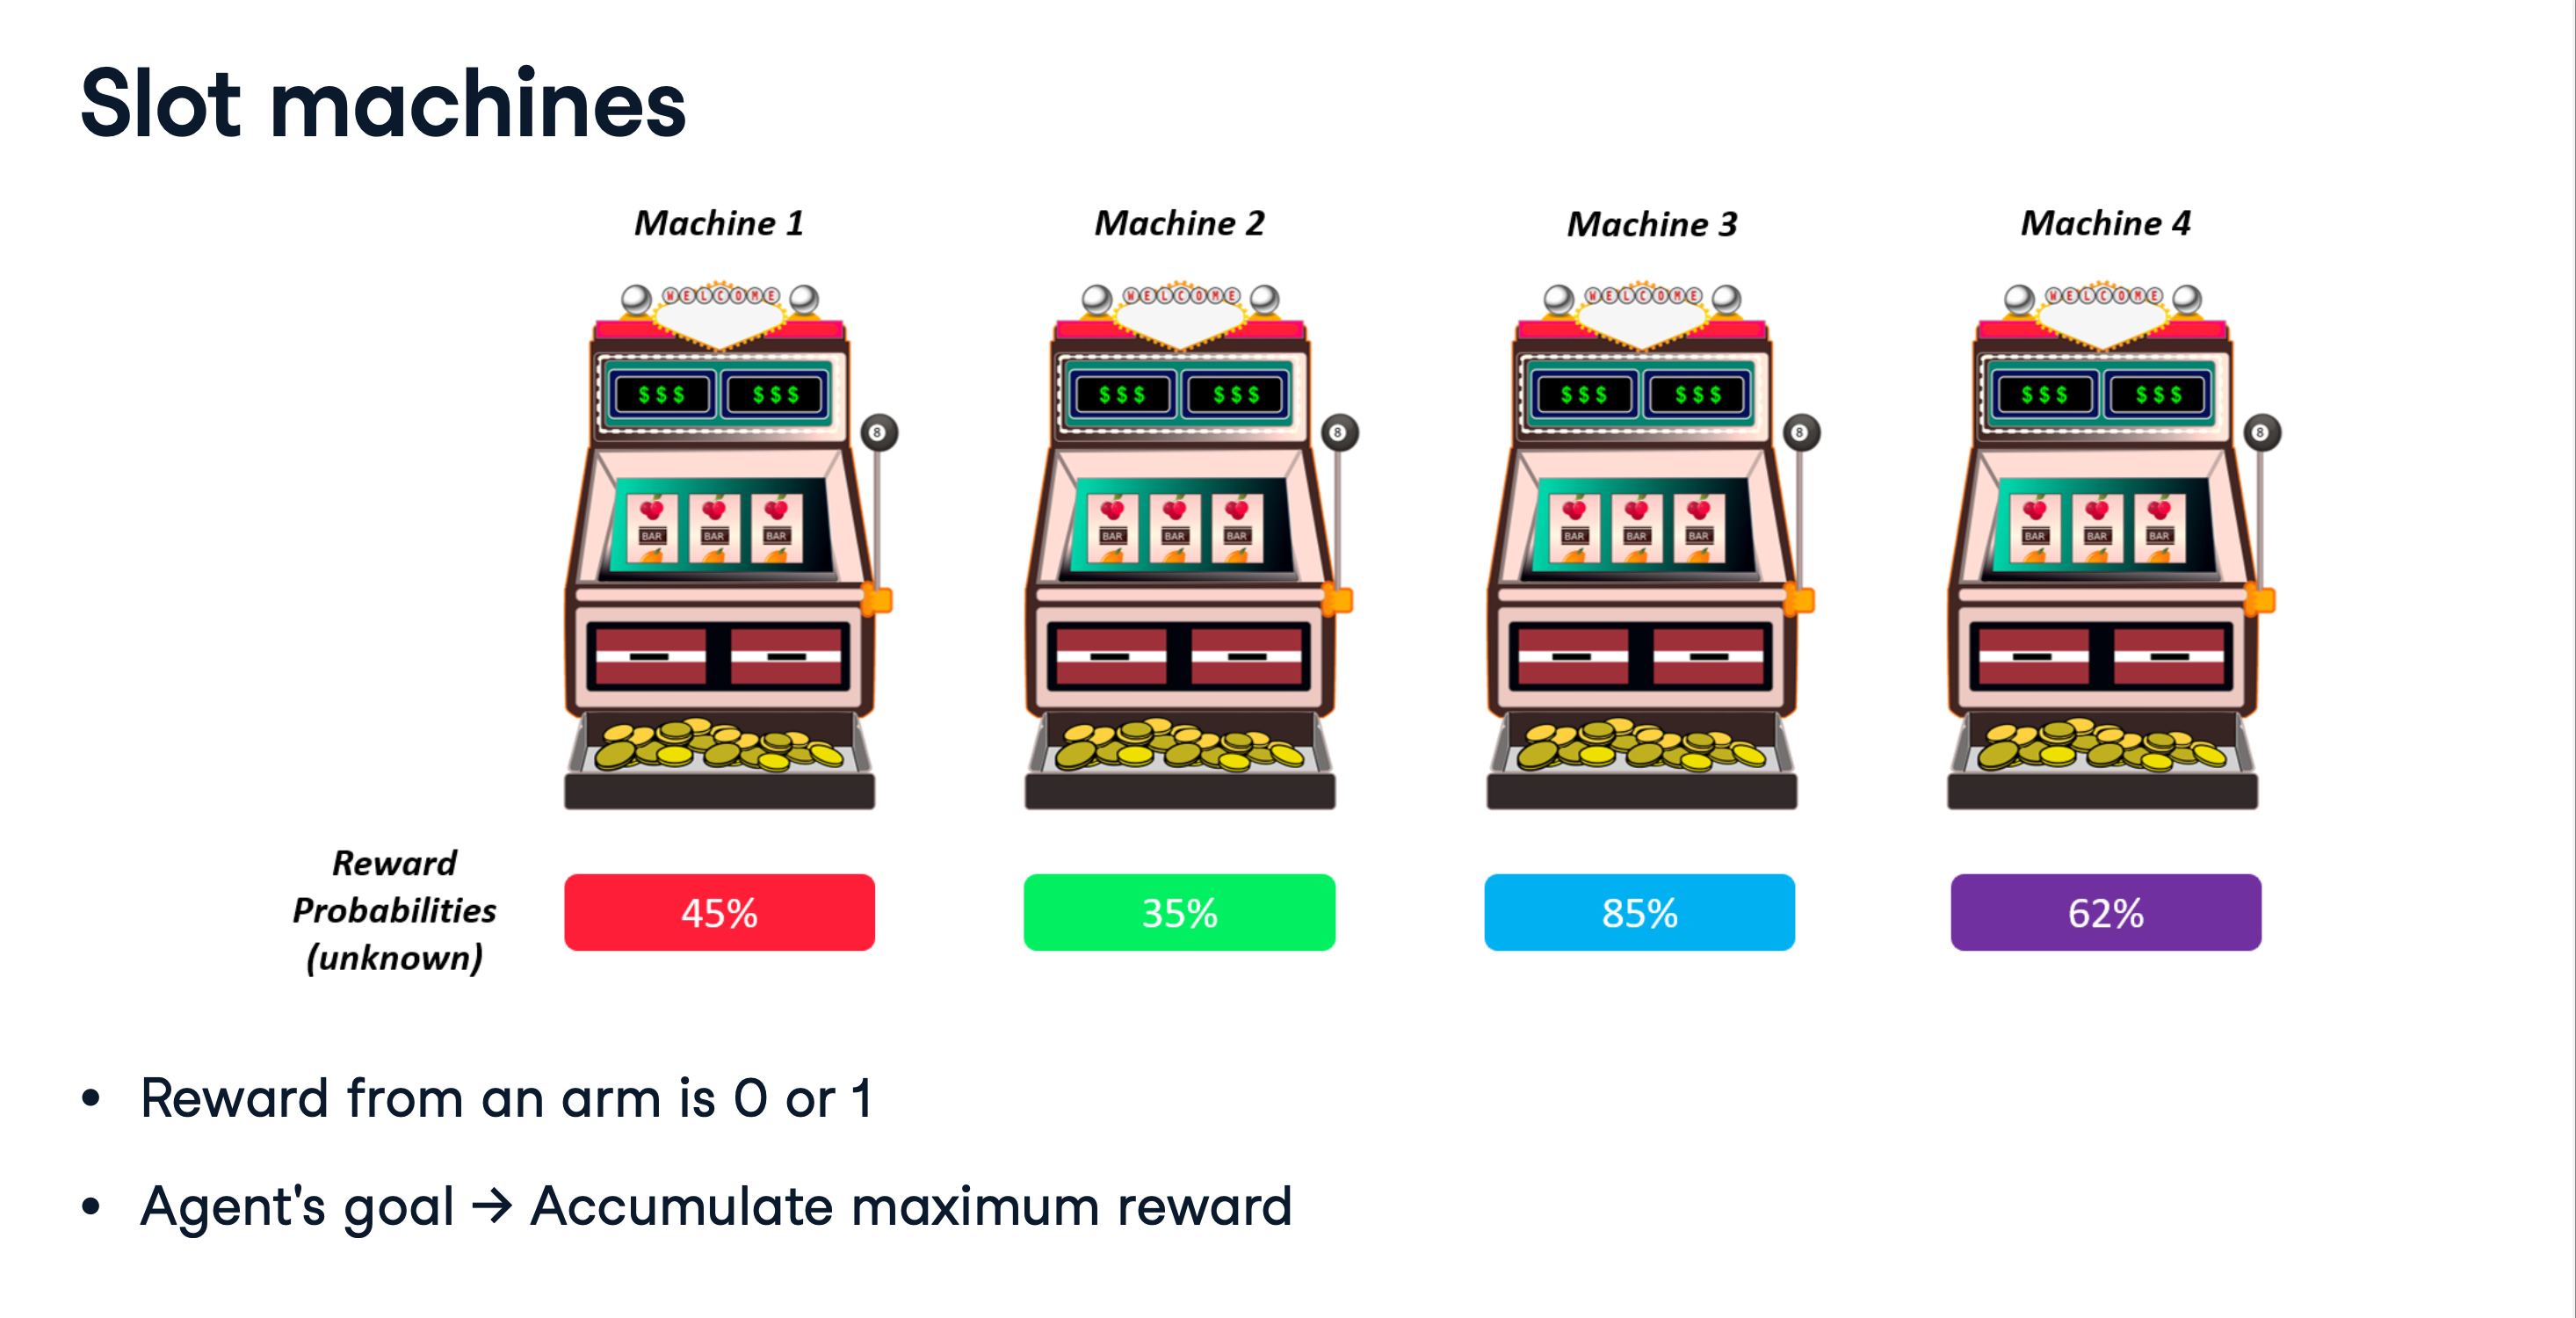

We consider the simplest reward distribution is the Bernoulli distribution, when the reward of each arm a can be either 1 or 0 (“success or failure”, “heads or tails”).

# **Bandit specification**

In [2]:
n_arms = 4 #Number of arms
true_bandit_probs = [0.45, 0.35, 0.85, 0.62] #True reward probability

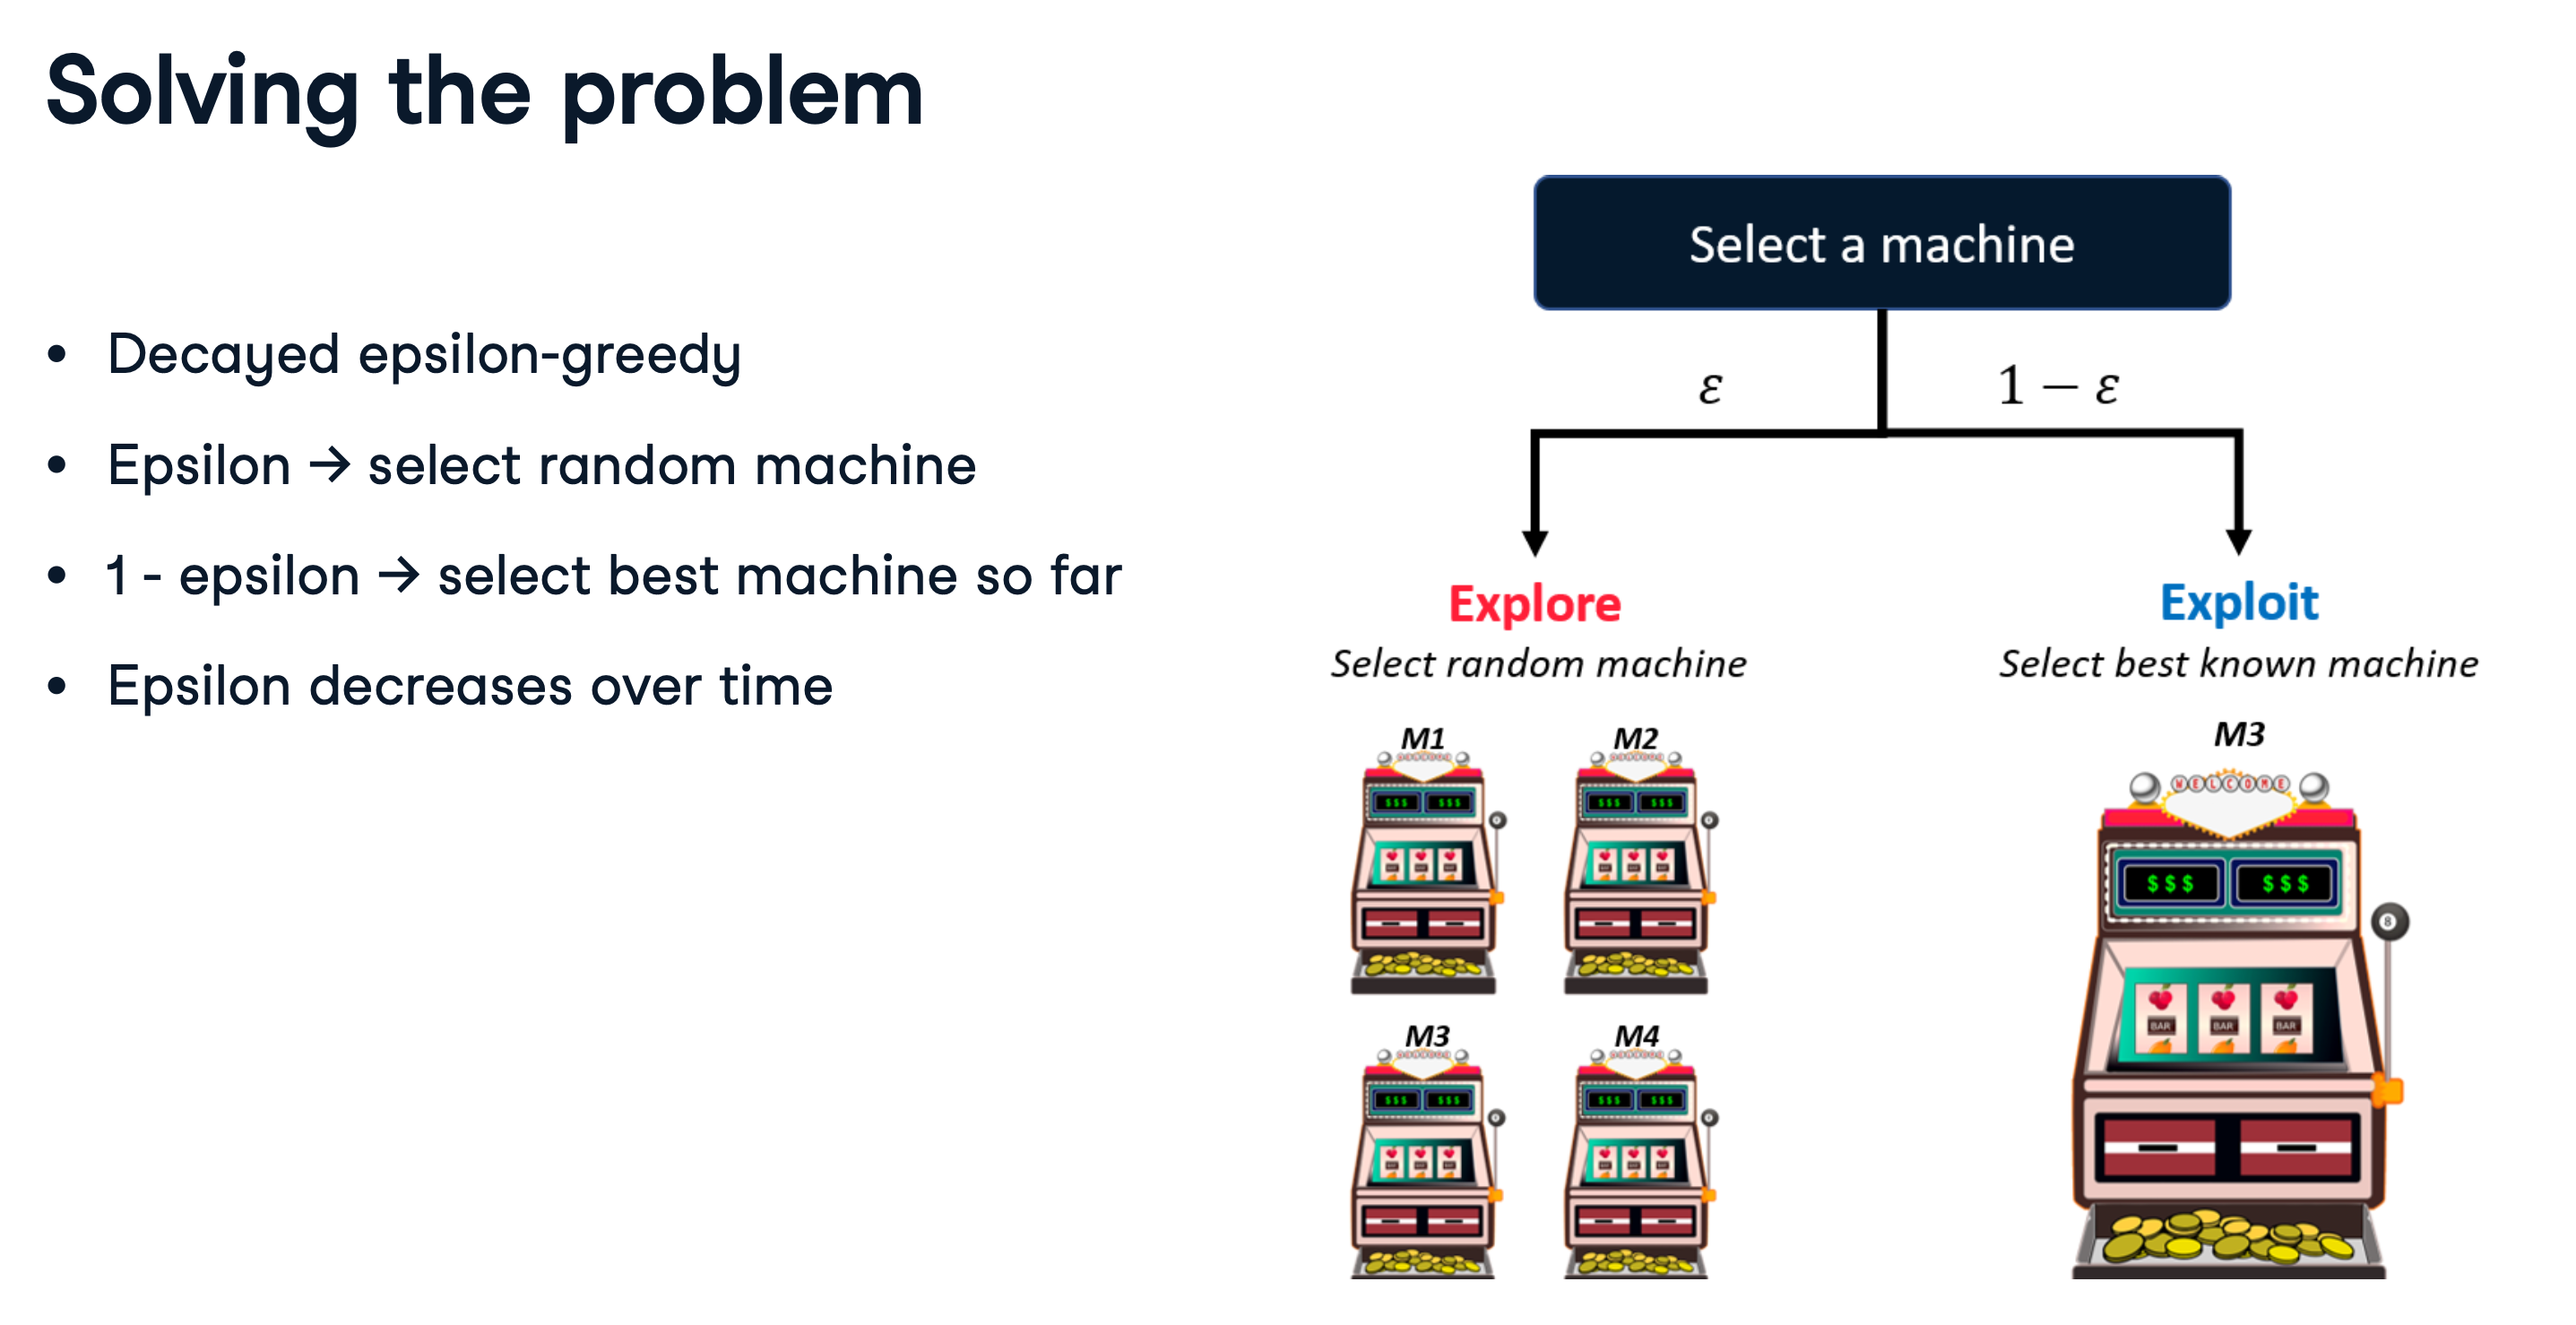

In [3]:
"""
epsilon - algorithm' param

values  - estimated reward probability of each arm
"""
def epsilon_greedy(epsilon, values):
  # If prob is not in epsilon, do exploitation of best arm so far
  if random.random() > epsilon:
    return np.argmax(values)
  # If prob falls in epsilon range, do exploration
  else:
    return random.randrange(len(values))

# **Initialization Bandits**

In [4]:
n_iterations = 100000  #Time horizon

"""
Bandit Specification
"""

n_arms = 4 #Number of arms
true_bandit_probs = [0.45, 0.35, 0.85, 0.62] #True reward probability

"""
Algorithm's params
"""
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.999

"""
Counters
"""
counts = np.zeros(n_arms)  # How many times each arm was played
values = np.zeros(n_arms)  # Estimated reward probability of each arm
rewards = np.zeros(n_iterations)  # Reward history
selected_arms = np.zeros(n_iterations, dtype=int)  # Arm selection history

# **Interaction loop**

$value_{n-1} = \frac{\sum_{i=1}^{n-1} reward_i}{counts_{n-1}}$

$ \sum_{i=1}^{n-1} reward_i = value_{n-1}\cdot counts_{n-1}$

$value_{n} = \frac{\sum_{i=1}^{n-1} reward_i + reward_n}{counts_{n}} = \frac{value_{n-1}\cdot (counts_{n}-1) + reward_n}{counts_{n}} = value_{n-1} + \frac{reward_n-value_{n-1}}{counts_{n}}$

In [5]:
for i in range(n_iterations):

  arm = epsilon_greedy(epsilon, values)

  #will we get a win (1) or not (0)?
  reward = np.random.rand() < true_bandit_probs[arm] #will we get a win or not?
  rewards[i] = reward

  #updating counters
  selected_arms[i] = arm
  counts[arm] += 1

  #WHY?
  values[arm] += (reward - values[arm]) / counts[arm]

  epsilon = max(min_epsilon, epsilon * epsilon_decay)

# **Analyzing selections**

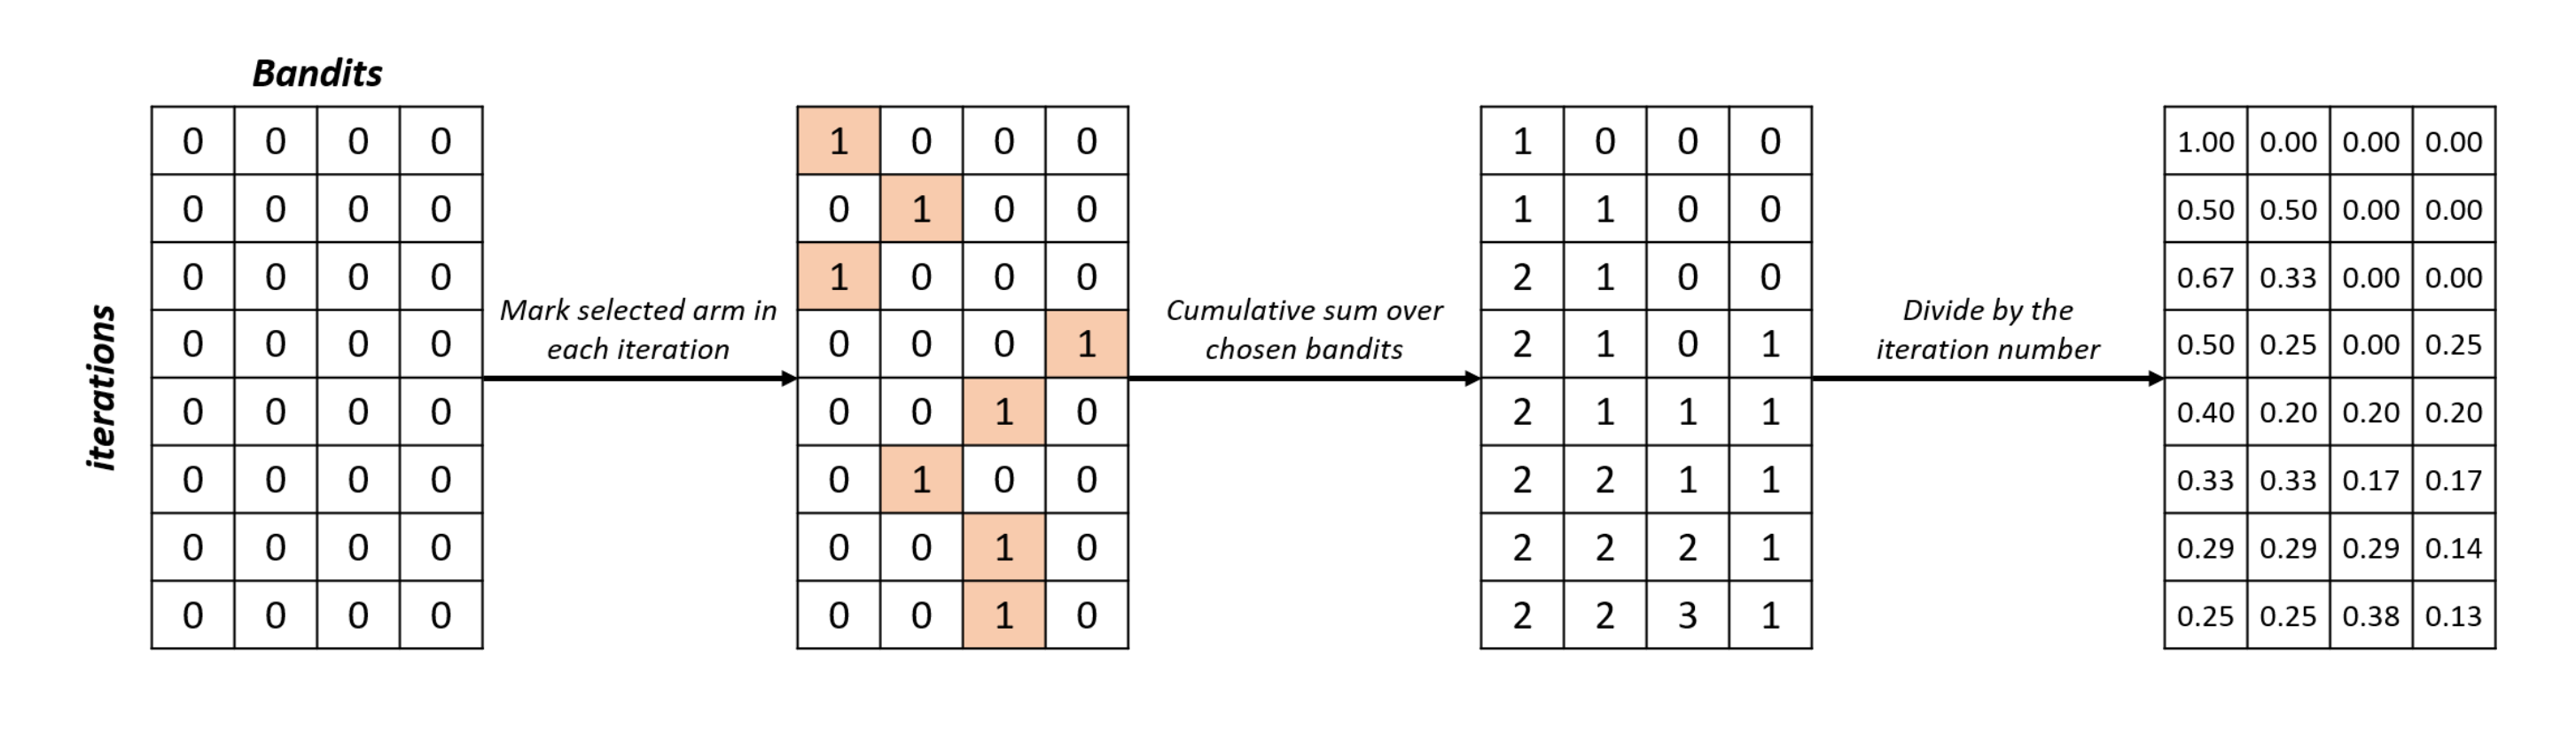

In [6]:
selections_percentage = np.zeros((n_iterations, n_arms))

for i in range(n_iterations):
    selections_percentage[i, selected_arms[i]] = 1

selections_percentage = np.cumsum(selections_percentage, axis=0) / np.arange(
    1, n_iterations + 1
).reshape(-1, 1)

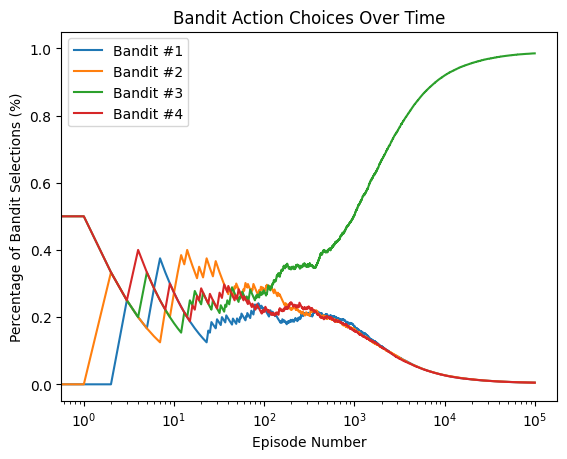

Bandit #1 -> 0.45
Bandit #2 -> 0.35
Bandit #3 -> 0.85
Bandit #4 -> 0.62


In [7]:
import matplotlib.pyplot as plt
for arm in range(n_arms):
    plt.plot(selections_percentage[:, arm], label=f'Bandit #{arm+1}')
plt.xscale('log')
plt.title('Bandit Action Choices Over Time')
plt.xlabel('Episode Number')
plt.ylabel('Percentage of Bandit Selections (%)')
plt.legend()
plt.show()
for i, prob in enumerate(true_bandit_probs, 1):
    print(f"Bandit #{i} -> {prob:.2f}")

# MAB

*   Reward
*   Regret

#Regret

**How do we argue whether an algorithm is doing a good job across different problem instances?** The problem is, some problem instances inherently allow higher rewards than others. One standard approach is to compare the algorithm’s cumulative reward to the **best-arm benchmark** $\mu^* \cdot T$ : the expected reward of always playing an optimal arm, which is the best possible total expected reward for a particular problem instance. Formally, we define the following quantity, called regret at round $T$:

# $R(T) = \mu^* \cdot T - \sum_{t=1}^T \mu(a_t)$

In [8]:
reward = np.sum(rewards)/ n_iterations

regret = np.max(true_bandit_probs) - np.sum(selections_percentage[-1, :] * n_iterations * true_bandit_probs)/ n_iterations

print(f'Reward {reward}')
print(f'Regret {regret}')

Reward 0.84125
Regret 0.005671700000000057


Indeed, this is how much the algorithm “regrets” not knowing the best arm in advance. Note that at, the arm chosen at round t, is a random quantity, as it may depend on randomness in rewards and/or in the algorithm.

So, **$R(T)$ is also a random variable**. We will typically talk about
* **expected regret** $\mathbb{E}[R(T)]$
* **realized regret** $R(T) = \mu^* \cdot T - \sum_{t=1}^T \mu(a_t)$ ( pseudo-regret )

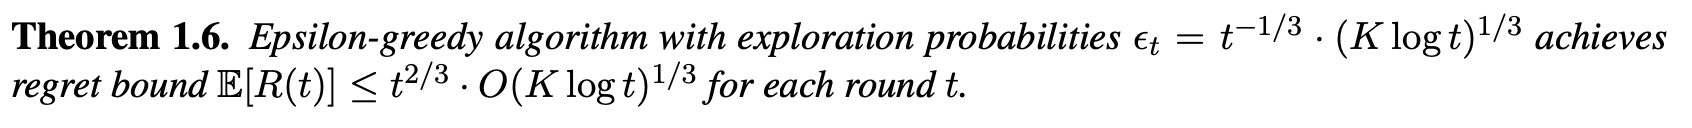

In [9]:
import numpy as np
from abc import ABC, abstractmethod

class MAB(ABC):
    """Base class for multi-armed bandit (MAB)

    Parameters
    ----------
    n_arms : int
        Number of arms.
    """
    # initialise
    def __init__(self, n_arms):
        self.n_arms = n_arms

    @abstractmethod
    def play(self):
        """Play a round

        Returns
        -------
        arm : int
            Integer index of the arm played this round. Should be in the set
            {0, ..., n_arms - 1}.
        """
        pass

    @abstractmethod
    def update(self, arm, reward):
        """Update the internal state of the MAB after a play

        Parameters
        ----------
        arm : int
            Integer index of the played arm in the set {0, ..., n_arms - 1}.

        reward : float
            Reward received from the arm.

        """
        self.arm = arm
        self.reward = reward

In [10]:
def offlineEvaluate(mab, true_bandit_probs, n_arms, n_rounds= 100000):
    """Offline evaluation of a multi-armed bandit

    Parameters
    ----------
    mab : instance of MAB
        MAB to evaluate.

    n_arms : int
        Number of arms.

    true_bandit_probs : float numpy.ndarray, shape (n_events,)
        Array containing the history of rewards.


    n_rounds : int, default=None
        Number of matching events to evaluate the MAB on.

    Returns
    -------
    R : float numpy.ndarray
        Rewards for the matching events.

    H : int numpy.ndarray
        Historical events
    """

    R = []          # save the total payoff
    H = np.zeros((n_rounds, n_arms)) # save used historical events

    for i in range(n_rounds):
        arm = mab.play()
        reward = np.random.rand() < true_bandit_probs[arm]

        R.append(reward)  # append the new rewards
        H[i, arm] = 1     # append the used events
        mab.update(arm, reward) # update the information

    return np.array(R), np.array(H)

In [11]:
class EpsGreedy(MAB):
    """Epsilon-Greedy multi-armed bandit

    Parameters
    ----------
    n_arms : int
        Number of arms

    epsilon : float
        Explore probability. Must be in the interval [0, 1].

    min_epsilon : float
        Min Explore probability. Must be in the interval [0, 1].

    epsilon_decay : float
         epsilon *= epsilon_decay


    """
    # initialise values
    def __init__(self, n_arms, epsilon, min_epsilon, epsilon_decay):
        super().__init__(n_arms)

        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay

        self.counts = np.zeros(n_arms)  # How many times each arm was played
        self.values = np.zeros(n_arms)  # Estimated reward probability of each arm
        self.rewards = np.zeros(n_iterations)  # Reward history

    # select a random arm to explore or a arm with best rewards to exploit, then return the arm
    def play(self):
        super().play()#context)
        # If prob is not in epsilon, do exploitation of best arm so far
        if random.random() > self.epsilon:
           return np.argmax(values)
        # If prob falls in epsilon range, do exploration
        else:
           return np.random.randint(0,self.n_arms)

    # update values
    def update(self, arm, reward):
        super().update(arm, reward)

        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)


In [12]:
n_arms = 4
n_iterations = 100000
true_bandit_probs = [0.45, 0.35, 0.85, 0.62]
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.999

In [13]:
mab = EpsGreedy(n_arms, epsilon, min_epsilon, epsilon_decay)
results_EpsGreedy, history_EpsGreedy = offlineEvaluate(mab, true_bandit_probs, n_arms, n_iterations)
print('EpsGreedy average reward', np.mean(results_EpsGreedy))

EpsGreedy average reward 0.84635


In [14]:
results_EpsGreedy

array([ True,  True,  True, ...,  True,  True,  True], shape=(100000,))

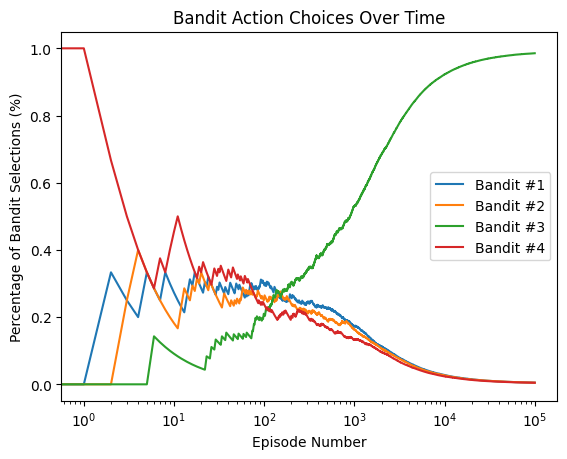

Bandit #1 -> 0.45
Bandit #2 -> 0.35
Bandit #3 -> 0.85
Bandit #4 -> 0.62


In [15]:
import matplotlib.pyplot as plt
selections_percentage = np.cumsum(history_EpsGreedy, axis=0) / np.arange(1, n_iterations + 1).reshape(-1, 1)

for arm in range(n_arms):
    plt.plot(selections_percentage[:, arm], label=f'Bandit #{arm+1}')
plt.xscale('log')
plt.title('Bandit Action Choices Over Time')
plt.xlabel('Episode Number')
plt.ylabel('Percentage of Bandit Selections (%)')
plt.legend()
plt.show()
for i, prob in enumerate(true_bandit_probs, 1):
    print(f"Bandit #{i} -> {prob:.2f}")

/tmp/ipykernel_462952/3424368796.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


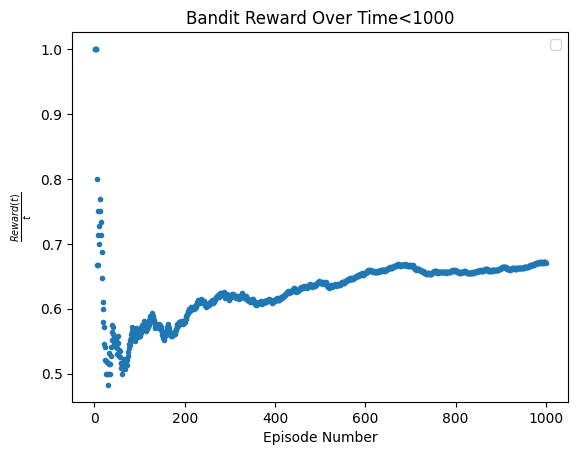

In [16]:
plt.plot(np.arange(1, n_iterations+1)[:1000], (np.cumsum(results_EpsGreedy)/np.arange(1, n_iterations+1))[:1000], '.')
plt.title(r'Bandit Reward Over Time<1000')
plt.xlabel('Episode Number')
plt.ylabel(r'$\frac{Reward(t)}{t}$')
plt.legend()
plt.show()

/tmp/ipykernel_462952/4206938142.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


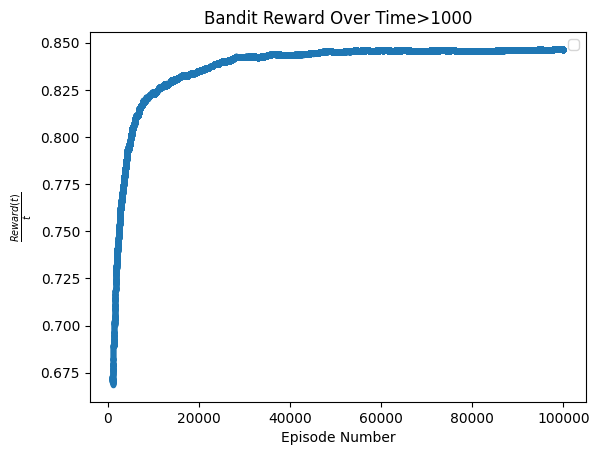

In [17]:
plt.plot(np.arange(1, n_iterations+1)[1000:], (np.cumsum(results_EpsGreedy)/np.arange(1, n_iterations+1))[1000:], '.')
plt.title(r'Bandit Reward Over Time>1000')
plt.xlabel('Episode Number')
plt.ylabel(r'$\frac{Reward(t)}{t}$')
plt.legend()
plt.show()

/tmp/ipykernel_462952/1109177393.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


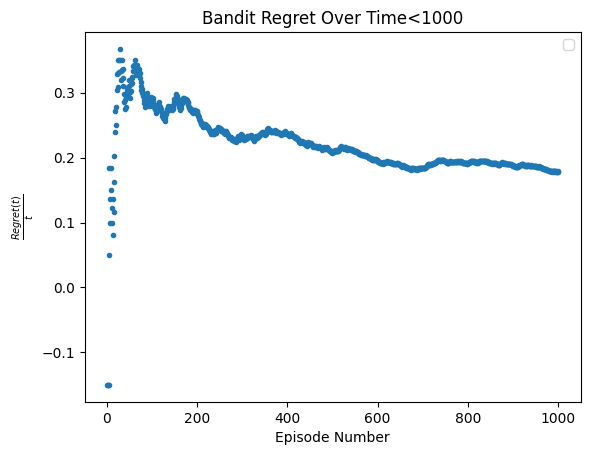

In [18]:
plt.plot(np.arange(1, n_iterations+1)[:1000], np.max(true_bandit_probs) - (np.cumsum(results_EpsGreedy)/np.arange(1, n_iterations+1))[:1000], '.')
plt.title(r'Bandit Regret Over Time<1000')
plt.xlabel('Episode Number')
plt.ylabel(r'$\frac{Regret(t)}{t}$')
plt.legend()
plt.show()

/tmp/ipykernel_462952/1179604972.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


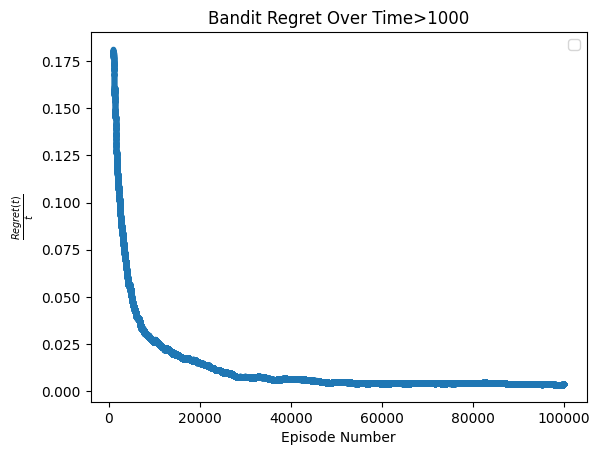

In [19]:
plt.plot(np.arange(1, n_iterations+1)[1000:], np.max(true_bandit_probs) - (np.cumsum(results_EpsGreedy)/np.arange(1, n_iterations+1))[1000:], '.')
plt.title(r'Bandit Regret Over Time>1000')
plt.xlabel('Episode Number')
plt.ylabel(r'$\frac{Regret(t)}{t}$')
plt.legend()
plt.show()

# UCB --------->>>>> HW
## class MAB - the same
## def offlineEvaluate - the same
## class EpsGreedy(MAB) --->>> class UCB(MAB)

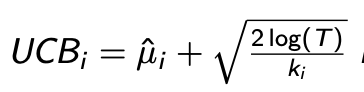

# Choose i = argmax(UCB_i)

In [38]:
class UCB(MAB):
    """Epsilon-Greedy multi-armed bandit

    Parameters
    ----------

    """

    def __init__(self, n_arms, T):
        super().__init__(n_arms)
        self.T = T
        self.arm_counts = np.zeros(n_arms)
        self.arm_sums = np.zeros(n_arms)
        self.n_iterations = 0

    def play(self):
        if self.n_iterations < self.n_arms * 3:
            arm = self.n_iterations % self.n_arms
            self.n_iterations += 1

        else:
            ucb_values = self.arm_sums / self.arm_counts + np.sqrt(
                2 * np.log(self.T) / self.arm_counts
            )
            lcb_values = self.arm_sums / self.arm_counts - np.sqrt(
                2 * np.log(self.T) / self.arm_counts
            )
            deactivation = np.where(ucb_values <= np.max(lcb_values), np.inf, 0)
            ucb_values -= deactivation
            arm = np.argmax(ucb_values)

        return arm

    def update(self, arm, reward):
        self.arm_counts[arm] += 1
        self.arm_sums[arm] += reward


In [59]:
n_arms = 4
n_iterations = 1000
true_bandit_probs = [0.45, 0.35, 0.85, 0.62]
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.95

In [62]:
mab = UCB(n_arms, T=n_iterations)
results_UCB, history_UCB = offlineEvaluate(mab, true_bandit_probs, n_arms, n_iterations)
print('UCB average reward', np.mean(results_UCB))

UCB average reward 0.78


In [63]:
mab = EpsGreedy(n_arms, epsilon=epsilon, min_epsilon=min_epsilon, epsilon_decay=epsilon_decay)
results_EpsGreedy, history_EpsGreedy = offlineEvaluate(mab, true_bandit_probs, n_arms, n_iterations)
print('EpsGreedy average reward', np.mean(results_EpsGreedy))

EpsGreedy average reward 0.829


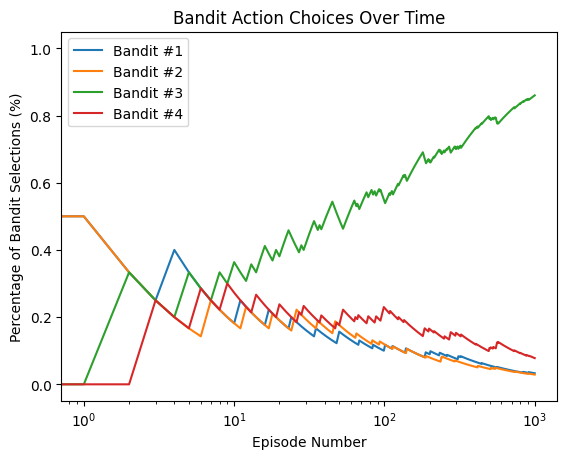

Bandit #1 -> 0.45
Bandit #2 -> 0.35
Bandit #3 -> 0.85
Bandit #4 -> 0.62


In [26]:
selections_percentage = np.cumsum(history_UCB, axis=0) / np.arange(1, n_iterations + 1).reshape(-1, 1)

import matplotlib.pyplot as plt
for arm in range(n_arms):
    plt.plot(selections_percentage[:, arm], label=f'Bandit #{arm+1}')
plt.xscale('log')
plt.title('Bandit Action Choices Over Time')
plt.xlabel('Episode Number')
plt.ylabel('Percentage of Bandit Selections (%)')
plt.legend()
plt.show()
for i, prob in enumerate(true_bandit_probs, 1):
    print(f"Bandit #{i} -> {prob:.2f}")